# **Tutorial:** Drawing a Bounding Box with OpenCV

In this tutorial, you will learn how to use the OpenCV library in Python to load an image and draw a bounding box around an object. This is a fundamental step before moving on to object detection with YOLO.

### **Step 1: Install OpenCV**

If you don't have OpenCV installed, you can install it using pip:

In [1]:
%pip install --upgrade opencv-python
%pip install --upgrade matplotlib

  Using cached opencv_python-5.0.0.93-cp37-abi3-macosx_13_0_arm64.whl.metadata (19 kB)
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
Using cached opencv_python-5.0.0.93-cp37-abi3-macosx_13_0_arm64.whl (48.3 MB)
Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl (5.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
  Attempting uninstall: opencv-python━━━━━━━━━━━ 0/2 [numpy]
    Found existing installation: opencv-python 4.11.0.862 [numpy]
    Uninstalling opencv-python-4.11.0.86:━━━ 0/2 [numpy]
      Successfully uninstalled opencv-python-4.11.0.860/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ultralytics 8.4.150 requires numpy!


Verify the installed version number:

In [ ]:
%pip show opencv-python

### **Step 2: Import Required Libraries**

Import the libraries you will use:

In [2]:
import cv2
from matplotlib import pyplot as plt

### **Step 3: Load the Image**

Use OpenCV's `imread` function to load your image.

Replace the path with the location of your image file.

In [4]:
# Load the image (change the path to your image file)
image_bgr = cv2.imread('/Users/eugenio/Documents/ComputerVision/UC.04 Object Detection/cat.jpg')

In [5]:
# Print the shape of the image (height, width, channels)
print('Image shape:', image_bgr.shape)

Image shape: (960, 940, 3)


### **Step 4: Show the image**

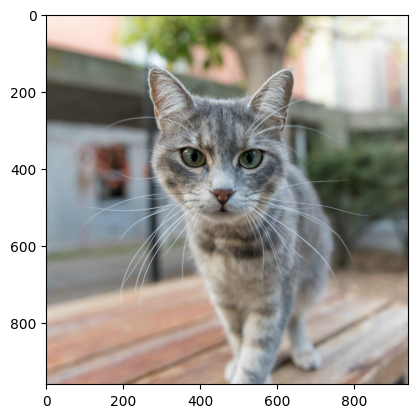

In [6]:
# Convert BGR to RGB for displaying with matplotlib
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb)
plt.show()

### **Step 5: Create the Bounding Box over the Image**

To draw a bounding box, use OpenCV's `rectangle` function.  

You need to specify the coordinates of the **top-left** point $(x1, y1)$ and the **bottom-right** point $(x2, y2)$ of the bounding box.

The coordinates should be within the image dimensions

In [7]:
x1, y1 = 250, 200  # Top-left corner
x2, y2 = 700, 900  # Bottom-right corner

# Draw the bounding box on the input image using cv2.rectangle
# Arguments: image, (x1, y1), (x2, y2), bounding box color in BGR, thickness
image_bgr_box = cv2.rectangle(image_bgr, (x1, y1), (x2, y2), (0, 255, 0), 15)  # Green box, thickness 15

### **Step 6: Display the Image and Bounding Box**

Finally, use matplotlib to display the image with the bounding box.

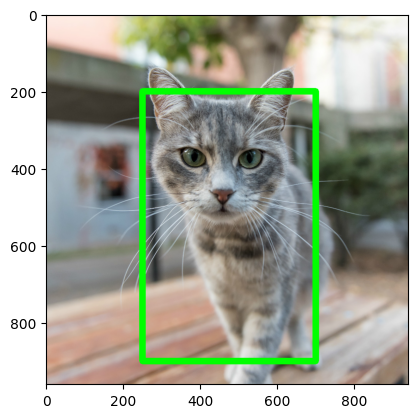

In [8]:
# Convert the image from BGR (OpenCV format) to RGB (matplotlib format)
image_rgb_box = cv2.cvtColor(image_bgr_box, cv2.COLOR_BGR2RGB)

# Display the image
plt.imshow(image_rgb_box)
plt.show()

You should now see your image with a bounding box drawn around the object.  

You can adjust the bounding box coordinates as needed to fit the object you want to highlight.

### **Individual Activity:**

1. Load an image containing **at least three different objects from different classes** using `cv2.imread`.

In [9]:
# Office objects on a white background (laptop, glasses, scissors, books, keys, clips...)
import cv2
from matplotlib import pyplot as plt  # already imported above, repeated so this section runs on its own

img = cv2.imread('../data/images/objetos_oficina.png')
if img is None:
    raise FileNotFoundError('Image not found, check the path')
print('Original shape:', img.shape)  # (height, width, channels)

# The image is small, so enlarge it 2x: thin objects (clips, key) still fit boxes of thickness 5
SCALE = 2
img = cv2.resize(img, None, fx=SCALE, fy=SCALE, interpolation=cv2.INTER_CUBIC)

# White margin on top so the labels of the upper boxes fit above them
TOP = 60
img = cv2.copyMakeBorder(img, TOP, 0, 0, 0, cv2.BORDER_CONSTANT, value=(255, 255, 255))
print('Working shape:', img.shape)

Original shape: (555, 740, 3)
Working shape: (1170, 1480, 3)


2. Draw **different colored bounding boxes** around each object (at least one of the bounding boxes should be yellow). Use a **line thickness** of 5 for each of the bounding boxes.

In [10]:
# One color (BGR) per class
COLORS = {
    'Clipboard':   (180, 0, 130),    # purple
    'Folder':      (0, 165, 255),    # orange
    'Laptop':      (0, 255, 0),      # green
    'Books':       (0, 0, 255),      # red
    'Magnifier':   (255, 255, 0),    # cyan
    'Glasses':     (147, 20, 255),   # pink
    'Key':         (255, 0, 0),      # blue
    'Clip':        (128, 128, 0),    # teal
    'Open book':   (19, 69, 139),    # brown
    'Abacus':      (0, 255, 255),    # yellow
    'Binder clip': (128, 128, 128),  # gray
    'Floppy disk': (255, 0, 255),    # magenta
    'Button':      (0, 128, 0),      # dark green
    'Computer':    (0, 0, 139),      # dark red
    'Glue':        (255, 191, 0),    # sky blue
    'Scissors':    (0, 255, 128),    # lime
    'Notebook':    (0, 128, 128),    # olive
}

# Every object: (class, (x1, y1, x2, y2)) measured on the original 740x555 image
objects = [
    ('Clipboard',   (12, 12, 110, 136)),
    ('Folder',      (113, 12, 217, 137)),
    ('Laptop',      (220, 12, 432, 136)),
    ('Books',       (435, 12, 606, 136)),
    ('Folder',      (608, 12, 729, 137)),
    ('Magnifier',   (12, 148, 72, 272)),
    ('Glasses',     (91, 148, 271, 272)),
    ('Key',         (290, 148, 350, 272)),
    ('Clip',        (368, 148, 401, 272)),
    ('Clip',        (404, 148, 437, 272)),
    ('Clip',        (441, 148, 473, 272)),
    ('Clip',        (477, 148, 510, 272)),
    ('Open book',   (528, 148, 728, 272)),
    ('Abacus',      (11, 285, 196, 408)),
    ('Binder clip', (242, 283, 389, 408)),
    ('Floppy disk', (436, 283, 557, 408)),
    ('Button',      (604, 283, 728, 407)),
    ('Computer',    (12, 419, 161, 543)),
    ('Glue',        (191, 419, 269, 543)),
    ('Scissors',    (300, 430, 338, 543)),
    ('Scissors',    (322, 419, 379, 543)),
    ('Glasses',     (409, 419, 600, 543)),
    ('Notebook',    (630, 419, 728, 543)),
]

def to_work(box):
    # original coordinates -> enlarged image with top margin
    x1, y1, x2, y2 = box
    return x1 * SCALE, y1 * SCALE + TOP, x2 * SCALE, y2 * SCALE + TOP

img_boxes = img.copy()  # keep the original image untouched
for name, box in objects:
    x1, y1, x2, y2 = to_work(box)
    cv2.rectangle(img_boxes, (x1, y1), (x2, y2), COLORS[name], 5)  # thickness 5

3. Add **text labels** above each bounding box (e.g., “Cat”, “Ball”, etc.) using `cv2.putText`.

In [11]:
font = cv2.FONT_HERSHEY_SIMPLEX
scale, text_thickness = 0.55, 1

def text_color(bgr):
    # White text on dark strips and black text on light strips, so every label is readable
    b, g, r = bgr
    return (255, 255, 255) if 0.299 * r + 0.587 * g + 0.114 * b < 140 else (0, 0, 0)

img_labeled = img_boxes.copy()
for name, box in objects:
    x1, y1, x2, y2 = to_work(box)
    color = COLORS[name]
    (w, h), _ = cv2.getTextSize(name, font, scale, text_thickness)
    # Filled strip above the box so the label is readable on any background
    cv2.rectangle(img_labeled, (x1, y1 - h - 10), (x1 + w + 8, y1), color, -1)
    cv2.putText(img_labeled, name, (x1 + 4, y1 - 5), font, scale, text_color(color), text_thickness, cv2.LINE_AA)

4. Display the **resulting image**.

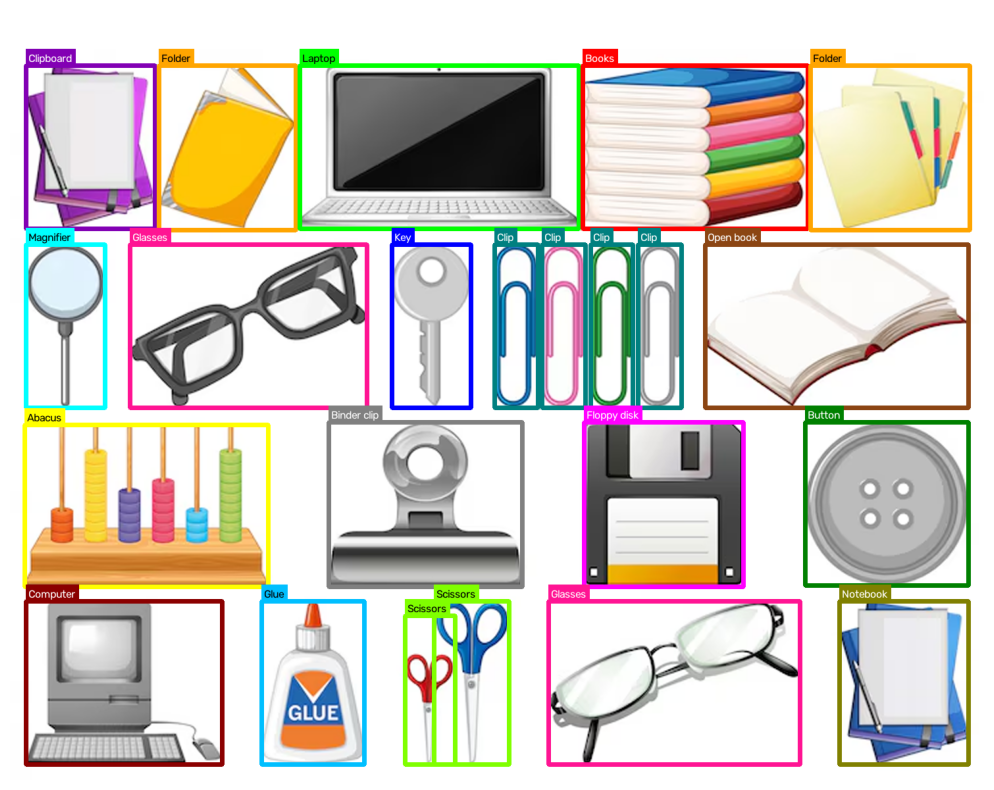

True

In [12]:
img_labeled_rgb = cv2.cvtColor(img_labeled, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 10))
plt.imshow(img_labeled_rgb)
plt.axis('off')
plt.show()

cv2.imwrite('../reports/resultado.png', img_labeled)  # copy of the result for the report

5. Suggest one method (written, no code) to **detect objects automatically** in an image (no manual coordinates). Name the model or technique you would use and briefly explain how it produces bounding boxes.

**Method: YOLO (You Only Look Once), for example YOLO26 or YOLOv8 pretrained on the COCO dataset.**

YOLO is a convolutional neural network that looks at the whole image in a single forward pass. The network extracts features at several scales and, for every location of the resulting grid, it directly predicts the box coordinates $(x, y, w, h)$, a confidence score that an object is there, and one probability per class (laptop, glasses, scissors, book, key...). No coordinates are written by hand.

The raw output has thousands of candidate boxes, so two filters are applied:
1. **Confidence threshold:** boxes with a low score are discarded.
2. **Non-Maximum Suppression (NMS):** when several boxes overlap the same object (high IoU), only the one with the highest score is kept.

The boxes that remain are the detections: each one has its coordinates, class name and confidence, and can be drawn directly with `cv2.rectangle` and `cv2.putText` exactly as in this activity. Because it runs in one pass, YOLO is fast enough for real-time video.

### **Grading Rubric:**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Image Loading** | 1 | Successfully loads an image with at least three objects using `cv2.imread`. Correct file path and proper handling of image object. |
| **2. Bounding Boxes** | 3 | Draws **different colored bounding boxes** around each object. Boxes have correct size and position, and line thickness is set to 5. |
| **3. Text Labels** | 2 | Adds **accurate text labels** above each bounding box using `cv2.putText`. Labels are readable and positioned correctly. |
| **4. Automatic Detection Suggestion** | 4 | Provides a clear and reasonable method to detect objects automatically. Shows understanding of dynamic object detection. |

Total: 10 points


<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>